In [1]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Import tqdm for the loading bar! 
# (notebook submodule makes it look pretty in Jupyter)
from tqdm.notebook import tqdm 

# ==========================================
# ⚙️ CONFIGURATION
# ==========================================
MOSAIC_PATH = "../data/output/canopy_height_mosaic.tif" # The file we want to analyze
PATCH_SIZE = 512          # The size of the grid squares to cut (512x512 pixels)
HEIGHT_THRESHOLD = 3.0    # Trees must be TALLER than 3.0 meters to be counted
COVERAGE_THRESHOLD = 0.75 # A patch must be at least 75% covered by trees to be "Dense"

# Quick safety check to make sure the file exists before we start
if not os.path.exists(MOSAIC_PATH):
    print(f"❌ Could not find {MOSAIC_PATH}. Please check the path.")
else:
    print(f"✅ Ready to analyze: {MOSAIC_PATH}")

✅ Ready to analyze: ../data/output/canopy_height_mosaic.tif


In [6]:
# Create empty lists to store our results
dense_canopy_patches = []
sparse_canopy_patches = []

RGB_PATH = "../data/input/sentinel2_rgb.tif" # <--- Point to your raw input

print("📂 Loading massive GeoTIFF into memory...")
with rasterio.open(MOSAIC_PATH) as src:
    chm_array = src.read(1)
    chm_array[chm_array == src.nodata] = np.nan
    height, width = chm_array.shape
    print(f"🗺️ Height Map loaded! Size: {width}x{height} pixels")

print("🎨 Loading and upscaling RGB to match height map coordinates...")
with rasterio.open(RGB_PATH) as src_rgb:
    # Read the RGB and explicitly force it to match the mosaic's (height, width)
    # This automatically handles the scale mismatch using cubic interpolation!
    rgb_bands = src_rgb.read(
        [1, 2, 3], 
        out_shape=(3, height, width),
        resampling=rasterio.enums.Resampling.cubic
    )
    # Apply the same smart stretch we used in the pipeline so it isn't dark
    rgb_array = np.transpose(rgb_bands, (1, 2, 0)).astype(np.float32)
    rgb_array = np.clip(rgb_array, 0, 3000) 
    rgb_array = ((rgb_array / 3000.0) * 255).astype(np.uint8)

# Calculate coordinates for the grid
coordinates = [
    (y, x) 
    for y in range(0, height, PATCH_SIZE) 
    for x in range(0, width, PATCH_SIZE)
]

# Loop through every coordinate
for y, x in tqdm(coordinates, desc="🌳 Analyzing Patches", unit="patch"):
    
    # Extract BOTH the height patch and the perfectly aligned RGB patch
    patch = chm_array[y : y + PATCH_SIZE, x : x + PATCH_SIZE]
    rgb_patch = rgb_array[y : y + PATCH_SIZE, x : x + PATCH_SIZE] # <--- New!
    
    if patch.shape != (PATCH_SIZE, PATCH_SIZE):
        continue
        
    if np.isnan(patch).sum() > (PATCH_SIZE * PATCH_SIZE * 0.5):
        continue
        
    tree_mask = patch >= HEIGHT_THRESHOLD
    coverage_percentage = np.mean(tree_mask)
    
    patch_info = {
        "coords": (x, y),
        "patch_data": patch,
        "rgb_data": rgb_patch, # <--- Save the RGB patch here
        "coverage": coverage_percentage
    }
    
    if coverage_percentage >= COVERAGE_THRESHOLD:
        dense_canopy_patches.append(patch_info)
    else:
        sparse_canopy_patches.append(patch_info)
        
print("✅ Done!")

📂 Loading massive GeoTIFF into memory...
🗺️ Height Map loaded! Size: 9995x14125 pixels
🎨 Loading and upscaling RGB to match height map coordinates...


/var/folders/nw/whndd4zx0yq8ggmr1g5hhd5m0000gn/T/ipykernel_91985/283390793.py:26: RuntimeWarning: invalid value encountered in cast
  rgb_array = ((rgb_array / 3000.0) * 255).astype(np.uint8)


🌳 Analyzing Patches:   0%|          | 0/560 [00:00<?, ?patch/s]

✅ Done!


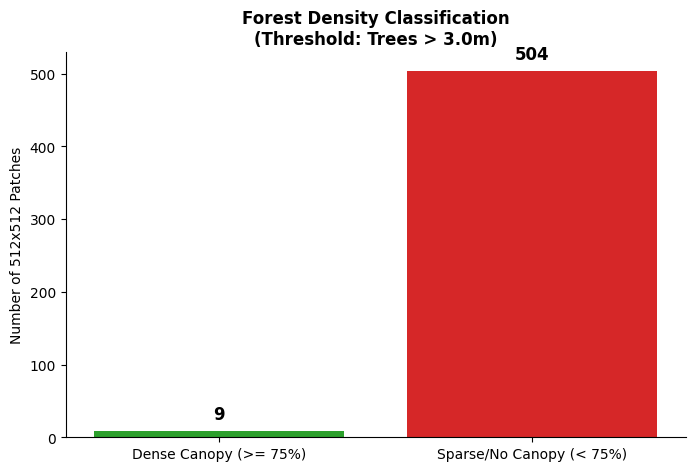

In [7]:
# Set up the data for the chart
categories = ['Dense Canopy (>= 75%)', 'Sparse/No Canopy (< 75%)']
counts = [len(dense_canopy_patches), len(sparse_canopy_patches)]
colors = ['#2ca02c', '#d62728'] # Green for dense, Red for sparse

# Create the figure
plt.figure(figsize=(8, 5))
bars = plt.bar(categories, counts, color=colors)
plt.title(f"Forest Density Classification\n(Threshold: Trees > {HEIGHT_THRESHOLD}m)", fontweight="bold")
plt.ylabel("Number of 512x512 Patches")

# Add the exact numbers hovering on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval + (max(counts) * 0.02), # slightly above the bar
        int(yval), 
        ha='center', va='bottom', fontweight='bold', fontsize=12
    )

# Clean up borders and show
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

--- Displaying Patches with >= 75% Canopy Coverage ---


/var/folders/nw/whndd4zx0yq8ggmr1g5hhd5m0000gn/T/ipykernel_91985/2718287495.py:44: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


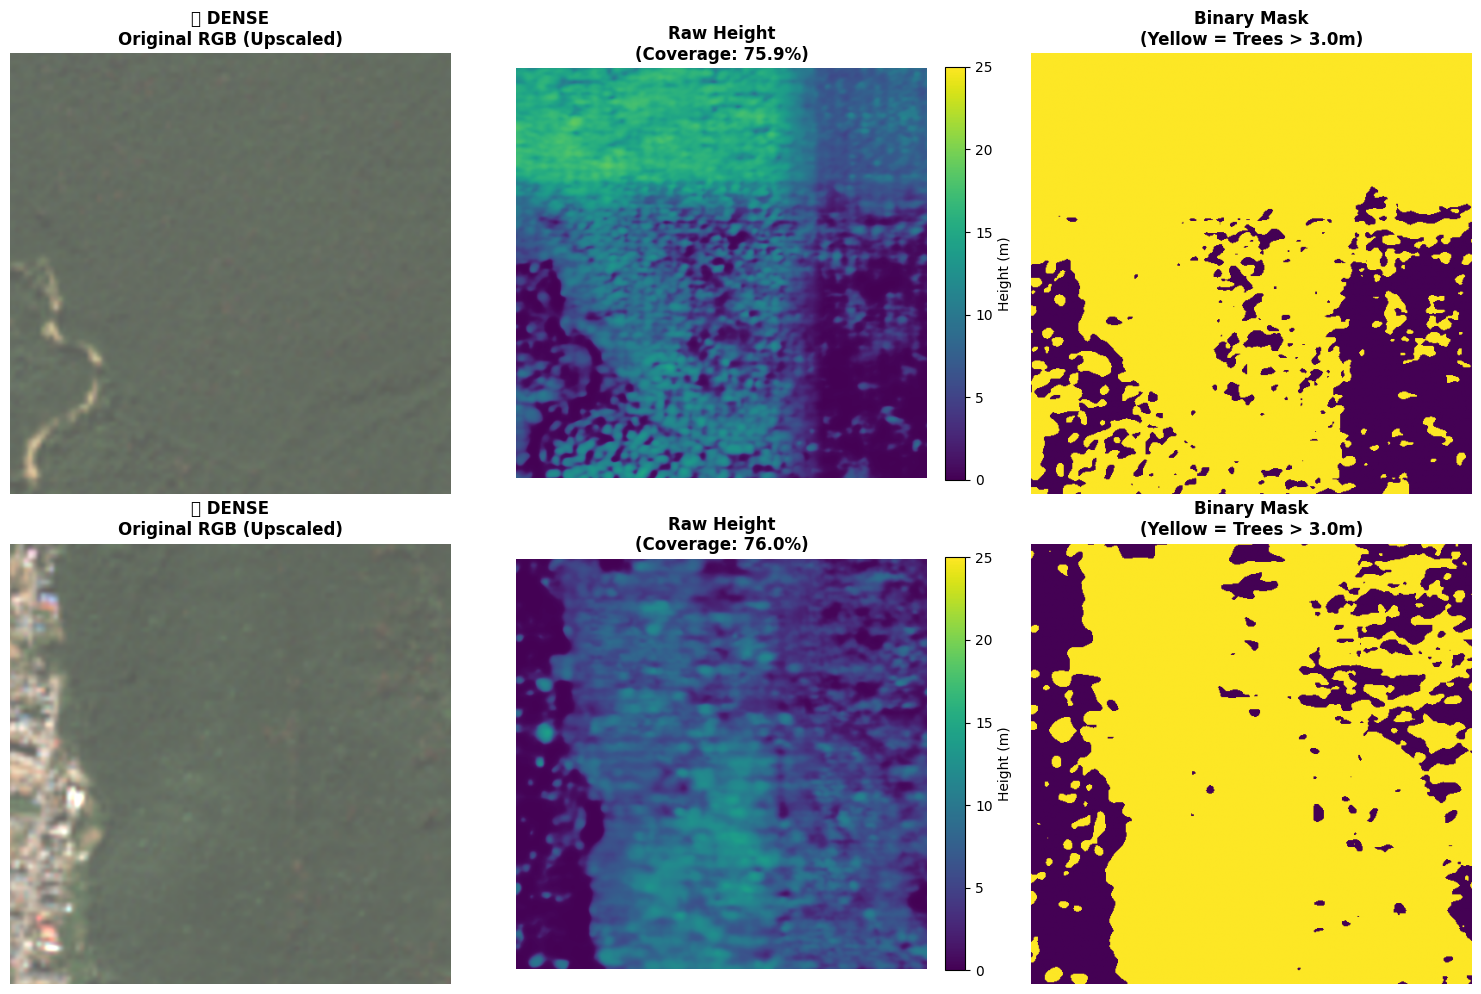


--- Displaying Patches with < 75% Canopy Coverage ---


/var/folders/nw/whndd4zx0yq8ggmr1g5hhd5m0000gn/T/ipykernel_91985/2718287495.py:44: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


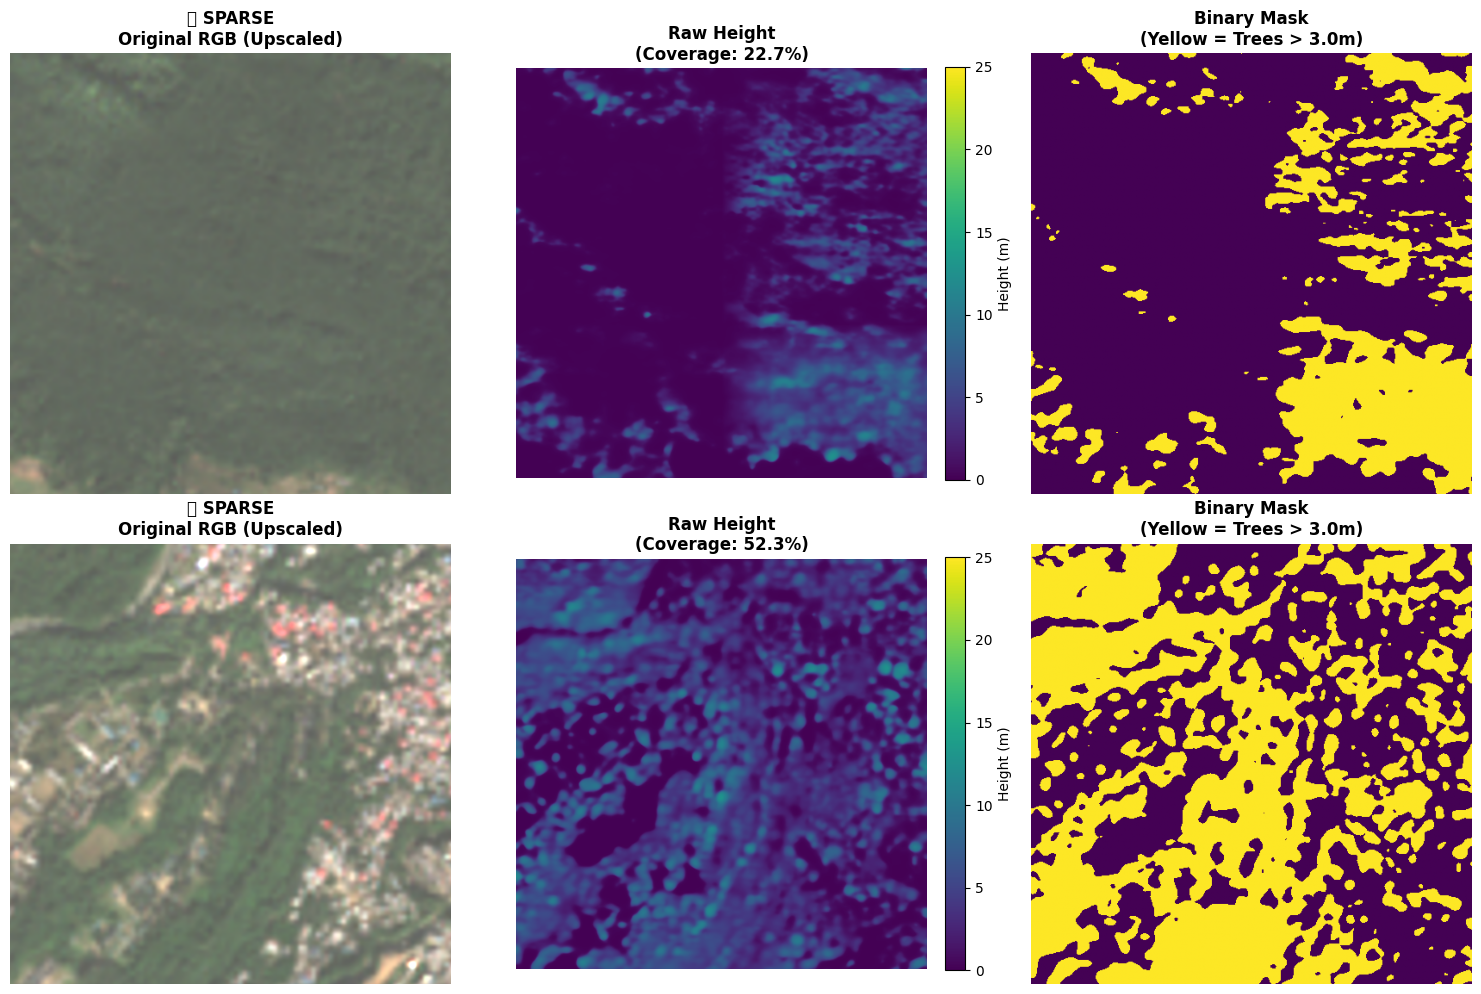

In [9]:
def plot_patch_examples(patch_list, title_prefix, num_examples=2):
    """Helper function to plot RGB, Height Heatmap, and Binary Mask."""
    if len(patch_list) == 0:
        print(f"⚠️ No patches found for {title_prefix}")
        return
        
    np.random.seed(42)
    sample_indices = np.random.choice(len(patch_list), min(num_examples, len(patch_list)), replace=False)
    
    # Change columns from 2 to 3, and widen the figure (figsize width from 10 to 15)
    fig, axes = plt.subplots(len(sample_indices), 3, figsize=(15, 5 * len(sample_indices)))
    
    if len(sample_indices) == 1:
        axes = [axes] 
        
    for i, idx in enumerate(sample_indices):
        data = patch_list[idx]
        patch_array = data["patch_data"]
        rgb_array = data["rgb_data"] # <--- Grab the RGB array
        coverage = data["coverage"] * 100 
        
        # --- LEFT PANEL: Original RGB ---
        ax0 = axes[i][0]
        ax0.imshow(rgb_array)
        ax0.set_title(f"{title_prefix}\nOriginal RGB (Upscaled)", fontweight="bold")
        ax0.axis('off')

        # --- MIDDLE PANEL: Raw Height Heatmap ---
        ax1 = axes[i][1]
        im1 = ax1.imshow(patch_array, cmap='viridis', vmin=0, vmax=25) 
        ax1.set_title(f"Raw Height\n(Coverage: {coverage:.1f}%)", fontweight="bold")
        ax1.axis('off')
        plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04, label="Height (m)")
        
        # --- RIGHT PANEL: Binary Mask ---
        ax2 = axes[i][2]
        binary_mask = patch_array >= HEIGHT_THRESHOLD
        cmap_binary = ListedColormap(['#440154', '#fde725'])
        
        ax2.imshow(binary_mask, cmap=cmap_binary)
        ax2.set_title(f"Binary Mask\n(Yellow = Trees > {HEIGHT_THRESHOLD}m)", fontweight="bold")
        ax2.axis('off')

    plt.tight_layout()
    plt.show()

print("--- Displaying Patches with >= 75% Canopy Coverage ---")
plot_patch_examples(dense_canopy_patches, "🟢 DENSE")

print("\n--- Displaying Patches with < 75% Canopy Coverage ---")
plot_patch_examples(sparse_canopy_patches, "🔴 SPARSE")